In [90]:
#import necessary libraries with ML model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import time
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

In [91]:
df = pd.read_csv('MortalityRisk_Predictions.csv')
df

,SEX,AGE,PNEUMONIA,PREGNANT,DIABETES,ASTHMA,INMSUPR,HIPERTENSION,CARDIOVASCULAR,COPD,RENAL_CHRONIC,OBESITY,TOBACCO,INTUBED,ICU,USMER,DIED,CLASIFFICATION_FINAL,PROBABILITY
0,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,3.0,0.014431
1,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,3.0,0.014431
2,1,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,3.0,0.013655
3,0,0,0.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,3.0,0.000000
4,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,3.0,0.013298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044645,1,119,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,3.0,0.000000
1044646,0,120,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,3.0,0.000000
1044647,0,120,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,3.0,0.000000
1044648,0,120,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,3.0,0.000000


In [92]:
start_time = time.time()


# Split the data into features and target variable
X = df.drop('DIED', axis=1)
y = df['DIED']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create the Random Forest Classifier
rf_classifier = RandomForestClassifier()

# Train the model
rf_classifier.fit(X_train, y_train)

# Predict the target variable for the test data
y_pred = rf_classifier.predict(X_train)

# Evaluate the accuracy of the model
#accuracy = accuracy_score(y_test, y_pred)
#print("Accuracy:", accuracy)
#X = df.drop('DIED', axis=1)  # Features without the 'DIED' column
#y = df['DIED']  # Target variable 'DIED'

# Create and train the logistic regression model
rf_classifier.fit(X, y)

# Predict probabilities for the whole dataset
df['PROBABILITY'] = rf_classifier.predict_proba(X)[:, 1]

# Print the updated DataFrame with the 'PROBABILITY' column
#df.to_csv('prediction_mortality.csv')
#show important features that were used for prediction mortality
importance_scores = rf_classifier.feature_importances_
importance_scores
import matplotlib.pyplot as plt
column_names = list(df.columns)



In [93]:
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, float('inf')]  # Note: '70+' corresponds to infinity

# Define labels for age distribution bins
age_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70+']

# Create a new column 'Age_Distribution' based on age bins and labels
df['Age_Distribution'] = pd.cut(df['AGE'], bins=age_bins, labels=age_labels, right=False)


In [94]:
#total_cases = len(df[(df['CLASIFFICATION_FINAL'] == 3) | (df['CLASIFFICATION_FINAL'] == 2) | (df['CLASIFFICATION_FINAL'] == 1)])
#print(total_cases)

Covidof3=df[(df['CLASIFFICATION_FINAL'] == 3)].groupby('Age_Distribution').size()
print(Covidof3)
InTotal_Cases=df[(df['CLASIFFICATION_FINAL'] != 0)].groupby('Age_Distribution').size()
print('total cases:',InTotal_Cases)

Age_Distribution
0-10      28349
10-20     38053
20-30    183914
30-40    245792
40-50    219656
50-60    161629
60-70     87456
70+       65576
dtype: int64
total cases: Age_Distribution
0-10      28572
10-20     38468
20-30    185293
30-40    247756
40-50    221767
50-60    163685
60-70     88966
70+       67028
dtype: int64


In [95]:
df['Mortality_Risk']=df['PROBABILITY']*100
#df
#age=len(df[(df['AGE']==0) & (df["DIED"] == 1) & (df["CLASIFFICATION_FINAL"] == 3) & (df["PROBABILITY"]>=0.8)])
#print(age)

In [96]:
df

,SEX,AGE,PNEUMONIA,PREGNANT,DIABETES,ASTHMA,INMSUPR,HIPERTENSION,CARDIOVASCULAR,COPD,...,OBESITY,TOBACCO,INTUBED,ICU,USMER,DIED,CLASIFFICATION_FINAL,PROBABILITY,Age_Distribution,Mortality_Risk
0,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0,0,3.0,0.013113,0-10,1.311259
1,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0,0,3.0,0.013113,0-10,1.311259
2,1,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0,0,3.0,0.014971,0-10,1.497105
3,0,0,0.0,0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1,0,3.0,0.000000,0-10,0.000000
4,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1,0,3.0,0.012950,0-10,1.294953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044645,1,119,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0,0,3.0,0.000000,70+,0.000000
1044646,0,120,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0,0,3.0,0.000000,70+,0.000000
1044647,0,120,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0,0,3.0,0.000000,70+,0.000000
1044648,0,120,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0,0,3.0,0.000000,70+,0.000000


the total 24571
24571
Age_Distribution
0-10       69
10-20      98
20-30     400
30-40     963
40-50    2572
50-60    5031
60-70    6797
70+      8641
dtype: int64
Total covid cases in severity 3 Age_Distribution
0-10      28349
10-20     38053
20-30    183914
30-40    245792
40-50    219656
50-60    161629
60-70     87456
70+       65576
dtype: int64


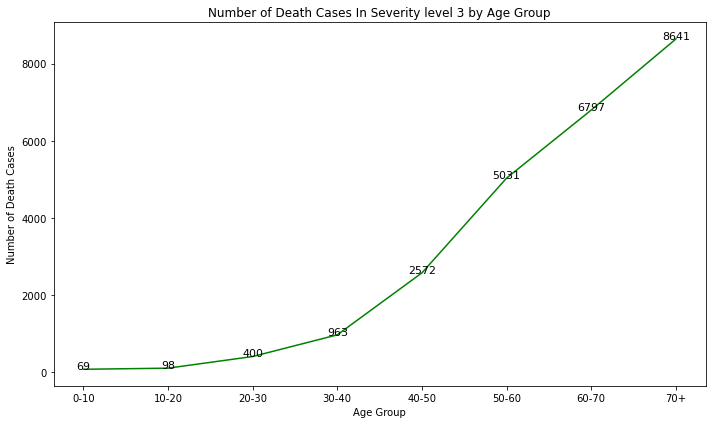

In [118]:

#No of people died with high severity and mortality greater then 0.8
No_of_Deaths = df[(df["DIED"] == 1) & (df["CLASIFFICATION_FINAL"] == 3) & (df["PROBABILITY"]>=0.8)].groupby('Age_Distribution').size()
Deaths=len(df[(df["DIED"] == 1) & (df["CLASIFFICATION_FINAL"] == 3) & (df["PROBABILITY"]>=0.8)])
isDead=No_of_Deaths.values.sum()
print('the total',Deaths)
print(isDead)
print(No_of_Deaths)
#print(Deaths)

inTotalDeaths=df[(df["DIED"] == 1) & (df["CLASIFFICATION_FINAL"] != 0) & (df["PROBABILITY"]>=0.8)].groupby('Age_Distribution').size()
#print('Total deaths',inTotalDeaths)
# Creation of a bar plot
#plt.figure(figsize=(10, 6))
#plt.bar(No_of_Deaths.index, No_of_Deaths.values, color='green')
print('Total covid cases in severity 3',Covidof3)
plt.figure(figsize=(10, 6))
plt.plot(No_of_Deaths.index, No_of_Deaths.values, color='green')
#print(df['Age_Distribution'])
for i in range(len(No_of_Deaths)):
    plt.text(No_of_Deaths.index[i], No_of_Deaths.values[i] + 0.2, str(No_of_Deaths.values[i]), ha='center', fontsize=11)

# Set labels and title
plt.xlabel('Age Group')
plt.ylabel('Number of Death Cases')
plt.title('Number of Death Cases In Severity level 3 by Age Group')
plt.xticks

# Display the plot
plt.tight_layout()
plt.show()

#intubed_by_age = df.groupby('AGE')['INTUBED'].sum()
#print(intubed_by_age)

In [9]:
#feature_importance = dict(zip(column_names, importance_scores))
#sorted_feature_importance = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

# Extract the sorted column names and importance scores
#sorted_columns, sorted_scores = zip(*sorted_feature_importance)

#print the values of the features 
#print(importance_scores)

# Plot the feature importance in a bar graph
#plt.figure(figsize=(10, 6))
#plt.bar(sorted_columns, sorted_scores)
#plt.xlabel('Features')
#plt.ylabel('Importance Scores')
#plt.title('Feature Importance')
#plt.xticks(rotation=90)
#plt.show()

In [10]:
import matplotlib.pyplot as plt

# Filter the data for Classification Final equal to 3
class_data = df[df['CLASIFFICATION_FINAL'] == 3]
class_data1 = len(df[df['CLASIFFICATION_FINAL'] == 3])
print(class_data1)

# Define the probability ranges
ranges = [(0.0, 0.25), (0.25, 0.50), (0.50, 0.75), (0.75, 1.0)]

# Initialize a list to store the range counts
range_counts = []

# Iterate over the probability ranges
for start, end in ranges:
    # Count the occurrences of each range within the data
    range_counts.append(((class_data['PROBABILITY'] >= start) & (class_data['PROBABILITY'] <= end)).sum())
print(range_counts)
sum_range_counts = sum(range_counts)
print(sum_range_counts)
# Create a bar graph for the range counts
#plt.bar(range(len(ranges)), range_counts)
#print(range_counts)
# Set the x-axis tick labels
#plt.xticks(range(len(ranges)), [f'{start}-{end}' for start, end in ranges])
# Set the y-axis label
#plt.ylabel('Count')
# Set the title for the graph
#plt.title('Probability Range Distribution for Classification Final 3')
# Show the plot
#plt.show()

1030425
[935410, 47024, 19867, 28124]
1030425


In [11]:
#total cases in mortality range


# Define the Mortality ranges
Mortality_ranges = [(0, 25), (25, 50), (50, 75), (75, 100)]

# Initialize lists to store range labels and total cases
range_labels = []
total_cases = []

# Iterate over the mortality ranges
for start, end in Mortality_ranges:
    # Filter the data within the current range
    filtered_data = df[(df['Mortality_Risk'] >= start) & (df['Mortality_Risk'] <= end)]
    
    # Calculate the total cases in the current range
    total_cases_in_range = len(filtered_data)
    
    range_labels.append(f'{start}-{end}')
    total_cases.append(total_cases_in_range)

# Print the range labels and total cases
for label, cases in zip(range_labels, total_cases):
    print(f'Mortality Range {label}: Total Cases = {cases}')


Mortality Range 0-25: Total Cases = 946462
Mortality Range 25-50: Total Cases = 47212
Mortality Range 50-75: Total Cases = 20043
Mortality Range 75-100: Total Cases = 30933


In [12]:
#pip install dash


In [119]:
import dash
import dash_core_components as dcc
import dash_html_components as html
from dash.dependencies import Input, Output
import pandas as pd
import plotly.express as px


age_bins = [0, 10, 20, 30, 40, 50, 60, 70, float('inf')]  # Note: '70+' corresponds to infinity

# Define labels for age distribution bins
age_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70+']

# Create a new column 'Age_Distribution' based on age bins and labels
df['Age_Distribution'] = pd.cut(df['AGE'], bins=age_bins, labels=age_labels, right=False)

# Calculate the percentage of probability for each age group
age_group_mortalities = df.groupby('Age_Distribution')['PROBABILITY'].mean() * 100

InTotal_Cases=df[(df['CLASIFFICATION_FINAL'] != 0)].groupby('Age_Distribution').size()



# Create a Dash app
app = dash.Dash(__name__)

# Define the layout of the app
app.layout = html.Div([
    dcc.Graph(id='age-group-probability'),
])

# Define a callback to update the graph
@app.callback(
    Output('age-group-probability', 'figure'),
    Input('age-group-probability', 'relayoutData')
)
def update_graph(relayoutData):
    fig = px.line(
        age_group_mortalities,
        x=age_group_mortalities.index,
        y=age_group_mortalities.values
        #labels={'x': 'Age Group', 'y': 'Average Probability (%)'},
        #title='Average Probability by Age Group'
    )
    
    # Add data labels for the percentage values
    for i in range(len(age_group_mortalities)):
        fig.add_annotation(
            x=age_group_mortalities.index[i],
            y=age_group_mortalities.values[i] + 0.5,
            text=f'{age_group_mortalities.values[i]:.2f}%',
            showarrow=False,
            align='center'
        )
        
    
    fig.update_layout(title = 'Average Mortality Risk by Age Group',
                      xaxis_title = 'Age Group',
                      yaxis_title = 'Average Mortality (%)'
                      )    
    return fig

# Run the app
if __name__ == '__main__':
    app.run_server(debug=True, port=8052)
#print('(0 to 9):',28572)
#print('(10 to 19):',38468)
print('total cases:',InTotal_Cases)
print(InTotal_Cases.values.sum())

total cases: Age_Distribution
0-10      28572
10-20     38468
20-30    185293
30-40    247756
40-50    221767
50-60    163685
60-70     88966
70+       67028
dtype: int64
1041535


In [121]:
import dash
import dash_core_components as dcc
import dash_html_components as html
from dash.dependencies import Input, Output
import pandas as pd
import plotly.express as px



'''# Define age groups and corresponding age range
age_distributions = ['0 to 10']#, '11 to 20', '21 to 30', '31 to 40', '41 to 50', '51 to 60', '61 to 70', '71+']
age_ranges = [(0, 10)]#, (11, 20), (21, 30), (31, 40), (41, 50), (51, 60), (61, 70), (71, float('inf'))]

#age_Distribution = ['0', '0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70+']
#age_Grp = [(0, 1), (1, 10), (10, 20), (20, 30), (30, 40), (40, 50), (50, 60), (60, 70), (70, float('inf'))]


# Create a new column 'AGE_GROUP' based on age ranges
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[range[0] for range in age_ranges] + [float('inf')], labels=age_distributions)
'''
# Calculate counts of intubated cases and pneumonia cases by age group
intubed_cases = df[(df["INTUBED"]==1) & (df["CLASIFFICATION_FINAL"]==3)].groupby('Age_Distribution')['INTUBED'].count()
pneumonia_cases = df[(df["PNEUMONIA"]==1) & (df["CLASIFFICATION_FINAL"]==3)].groupby('Age_Distribution')['PNEUMONIA'].count()
#print(intubed_cases)

#calculation for intubed
Total_intubed_age_groups = intubed_cases.values.sum()
print('Sumummation of age group values for intubed', Total_intubed_age_groups)

Total_intubed=len(df[(df["INTUBED"]==1) & (df["CLASIFFICATION_FINAL"]==3)])
print('Total cases with intubed in CLASIFFICATION_FINAL 3',Total_intubed)

#Calculation for pneumonia
#print(pneumonia_cases)
Total_pneumonia_age_groups=pneumonia_cases.values.sum()
print('Sumummation of age group values for pneumonia', Total_pneumonia_age_groups)

Total_pneumonia=len(df[(df["PNEUMONIA"]==1) & (df["CLASIFFICATION_FINAL"]==3)])
print('Total cases with pneumonia CLASIFFICATION_FINAL 3',Total_pneumonia)

InTotal_Cases=df[(df['CLASIFFICATION_FINAL'] != 0)].groupby('Age_Distribution').size()
print('total cases:',InTotal_Cases)
print(InTotal_Cases.values.sum())

# Create a Dash app
app = dash.Dash(__name__)

# Define the layout of the app
app.layout = html.Div([
    dcc.Graph(id='cases-by-age-group'),
])

# Define a callback to update the graph
@app.callback(
    Output('cases-by-age-group', 'figure'),
    Input('cases-by-age-group', 'relayoutData')
)
def update_graph(relayoutData):
    fig = px.line(
        df,
        x=intubed_cases.index,
        y=intubed_cases.values
        #labels={'x': 'Age Group', 'y': 'Number of cases'},
        #title='Number of Intubed and Pneumonia Cases by Age Group'
    )
    
    # Add data labels for intubed cases
    for i in range(len(intubed_cases)):
        fig.add_annotation(
            x=intubed_cases.index[i],
            y=intubed_cases.values[i] + 100,
            text=str(intubed_cases.values[i]),
            showarrow=False,
            align='center'
        )
    
    # Create a line plot for pneumonia cases
    fig.add_scatter(
        x=pneumonia_cases.index,
        y=pneumonia_cases.values,
        mode='lines+markers',
        name='Pneumonia Cases'
    )
    fig.add_scatter(
        x=intubed_cases.index,
        y=intubed_cases.values,
        mode='lines+markers',
        name='intubed_cases'
    )
    # Add data labels for pneumonia cases
    for i in range(len(pneumonia_cases)):
        fig.add_annotation(
            x=pneumonia_cases.index[i],
            y=pneumonia_cases.values[i] - 100,
            text=str(pneumonia_cases.values[i]),
            showarrow=False,
            align='center'
        )
    
    fig.update_layout(title = 'Number of Intubed and Pneumonia Cases in Classification final 3 by Age Group',
                      xaxis_title = 'Age Group',
                      yaxis_title = 'Number of cases'
                      )      
    return fig

# Run the app
if __name__ == '__main__':
    app.run_server(debug=True, port=8052)
    
    
intubed_cases_Total = df[(df["INTUBED"]==1) & (df["CLASIFFICATION_FINAL"]!=0)].groupby('Age_Distribution')['INTUBED'].count()
print('In total Intubed cases all CLASIFFICATION_FINAL ',intubed_cases_Total)
pneumonia_cases_Total = df[(df["PNEUMONIA"]==1) & (df["CLASIFFICATION_FINAL"]!=0)].groupby('Age_Distribution')['PNEUMONIA'].count()
print('In total pneumonia cases all CLASIFFICATION_FINAL',pneumonia_cases_Total)


Sumummation of age group values for intubed 32469
Total cases with intubed in CLASIFFICATION_FINAL 3 32469
Sumummation of age group values for pneumonia 136129
Total cases with pneumonia CLASIFFICATION_FINAL 3 136129
total cases: Age_Distribution
0-10      28572
10-20     38468
20-30    185293
30-40    247756
40-50    221767
50-60    163685
60-70     88966
70+       67028
dtype: int64
1041535


In total Intubed cases all CLASIFFICATION_FINAL  Age_Distribution
0-10      906
10-20     331
20-30     903
30-40    2157
40-50    4804
50-60    7919
60-70    8556
70+      7962
Name: INTUBED, dtype: int64
In total pneumonia cases all CLASIFFICATION_FINAL Age_Distribution
0-10      3523
10-20     1581
20-30     7382
30-40    15826
40-50    24457
50-60    30903
60-70    27918
70+      27581
Name: PNEUMONIA, dtype: int64


In [15]:
"""

# Filter the data for Classification Final equal to 3
Mortality_data = df[df['CLASIFFICATION_FINAL'] == 3]

# Define the Mortality ranges
Mortality_ranges = [(0.0, 0.25), (0.25, 0.50), (0.50, 0.75), (0.75, 1.0)]

# Initialize lists to store range labels and counts
range_labels = []
range_counts = []

# Iterate over the probability ranges
for start, end in Mortality_ranges:
    # Count the occurrences of each range within the data
    range_count = ((Mortality_data['PROBABILITY'] >= start) & (Mortality_data['PROBABILITY'] < end)).sum()
    range_counts.append(range_count)
    range_labels.append(f'{start:.2f}-{end:.2f} ({range_count})')

# Create a Dash app
app = dash.Dash(__name__)

# Define the layout of the app
app.layout = html.Div([
    dcc.Graph(id='mortality-range-distribution'),
])

# Define a callback to update the graph
@app.callback(
    Output('mortality-range-distribution', 'figure'),
    Input('mortality-range-distribution', 'relayoutData')
)
def update_graph(relayoutData):
    fig = px.line(
        x=range_labels,
        y=range_counts,
        labels={'x': 'Mortality Range', 'y': 'Number of cases'},
        title='Mortality Range Distribution for High Severity'
    )
    
    # Add data labels
    for i, count in enumerate(range_counts):
        fig.add_annotation(
            x=range_labels[i],
            y=count + 50,
            text=str(count),
            showarrow=False,
            align='center',
            font=dict(size=12)
        )
    
    fig.update_xaxes(tickangle=90)
    
    return fig

# Run the app
if __name__ == '__main__':
    app.run_server(debug=True)
"""

"\n\n# Filter the data for Classification Final equal to 3\nMortality_data = df[df['CLASIFFICATION_FINAL'] == 3]\n\n# Define the Mortality ranges\nMortality_ranges = [(0.0, 0.25), (0.25, 0.50), (0.50, 0.75), (0.75, 1.0)]\n\n# Initialize lists to store range labels and counts\nrange_labels = []\nrange_counts = []\n\n# Iterate over the probability ranges\nfor start, end in Mortality_ranges:\n    # Count the occurrences of each range within the data\n    range_count = ((Mortality_data['PROBABILITY'] >= start) & (Mortality_data['PROBABILITY'] < end)).sum()\n    range_counts.append(range_count)\n    range_labels.append(f'{start:.2f}-{end:.2f} ({range_count})')\n\n# Create a Dash app\napp = dash.Dash(__name__)\n\n# Define the layout of the app\napp.layout = html.Div([\n    dcc.Graph(id='mortality-range-distribution'),\n])\n\n# Define a callback to update the graph\n@app.callback(\n    Output('mortality-range-distribution', 'figure'),\n    Input('mortality-range-distribution', 'relayoutData')

In [120]:
import dash
import dash_core_components as dcc
import dash_html_components as html
from dash.dependencies import Input, Output
import pandas as pd
import plotly.express as px

# Assume you have your data loaded into a DataFrame named 'df'

# Define the Mortality ranges
Mortality_ranges = [(0, 25), (25, 50), (50, 75), (75, 100)]

# Initialize a Dash app
app = dash.Dash(__name__)

# Define the layout of the app
app.layout = html.Div([
    dcc.Graph(id='mortality-range-distribution-1'),
    dcc.Graph(id='mortality-range-distribution-2'),
    dcc.Graph(id='mortality-range-distribution-3'),
])

# Define a callback to update each graph based on the selected classification
@app.callback(
    Output('mortality-range-distribution-1', 'figure'),
    Output('mortality-range-distribution-2', 'figure'),
    Output('mortality-range-distribution-3', 'figure'),
    Input('mortality-range-distribution-1', 'relayoutData'),
    Input('mortality-range-distribution-2', 'relayoutData'),
    Input('mortality-range-distribution-3', 'relayoutData'),
)
def update_graphs(relayoutData1, relayoutData2, relayoutData3):
    fig1 = create_mortality_range_graph(Mortality_ranges, df, 1)
    fig2 = create_mortality_range_graph(Mortality_ranges, df, 2)
    fig3 = create_mortality_range_graph(Mortality_ranges, df, 3)
    
    return fig1, fig2, fig3

# Create a function to generate a mortality range graph for a given classification
def create_mortality_range_graph(Mortality_ranges, df, classification):
    Mortality_data = df[df['CLASIFFICATION_FINAL'] == classification]

    # Initialize lists to store range labels and counts
    range_labels = []
    range_counts = []

    # Iterate over the mortality ranges
    for start, end in Mortality_ranges:
        # Count the occurrences of each range within the data
        range_counting = ((Mortality_data['Mortality_Risk'] >= start) & (Mortality_data['Mortality_Risk'] <= end)).sum()
        range_counts.append(range_counting)
        range_labels.append(f'{start}%-{end}%')

    fig = px.bar(
        x=range_labels,
        y=range_counts,
        labels={'x': 'Mortality Range', 'y': 'Number of cases'},
        title=f'Mortality Range Distribution for Classification {classification}'
    )

    return fig

# Run the app
if __name__ == '__main__':
    app.run_server(debug=True, port=8052)
    
#print(range_counting)


In [55]:

''''
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, float('inf')]  # Note: '70+' corresponds to infinity
age_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70+']
df['Age_Distribution'] = pd.cut(df['AGE'], bins=age_bins, labels=age_labels, right=False)
age_group_mortalities = df.groupby('Age_Distribution')['PROBABILITY'].mean() * 100

# Create a Dash app
app = dash.Dash(__name__)

# Define the layout of the app
app.layout = html.Div([
    dcc.Graph(id='age-group-probability'),
])

# Define a callback to update the graph
@app.callback(
    Output('age-group-probability', 'figure'),
    Input('age-group-probability', 'relayoutData')
)
def update_graph(relayoutData):
    fig = px.line(
        age_group_mortalities,
        x=age_group_mortalities.index,
        y=age_group_mortalities.values,
    )

    # Add data labels for the percentage values
    for i in range(len(age_group_mortalities)):
        fig.add_annotation(
            x=age_group_mortalities.index[i],
            y=age_group_mortalities.values[i] + 0.5,
            text=f'{age_group_mortalities.values[i]:.2f}%',
            showarrow=False,
            align='center',
        )

    fig.update_layout(
        title='Average Mortality Risk by Age Group',
        xaxis_title='Age Group',
        yaxis_title='Average Mortality (%)',
    )

    # Add table annotations beside the x-axis
    for i, age_label in enumerate(age_labels):
        total_cases = InTotal_Cases.get(age_label, 0)
        fig.add_annotation(
            x=age_label,
            y=-0.15,  # Adjust the vertical position as needed
            text=f'{total_cases}',
            showarrow=False,
            align='center',
            font=dict(size=10),
            xref='x2',  # Reference the x-axis2
        )

    return fig

# Run the app
if __name__ == '__main__':
    app.run_server(debug=True, port=8052)'''



"'\nage_bins = [0, 10, 20, 30, 40, 50, 60, 70, float('inf')]  # Note: '70+' corresponds to infinity\nage_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70+']\ndf['Age_Distribution'] = pd.cut(df['AGE'], bins=age_bins, labels=age_labels, right=False)\nage_group_mortalities = df.groupby('Age_Distribution')['PROBABILITY'].mean() * 100\n\n# Create a Dash app\napp = dash.Dash(__name__)\n\n# Define the layout of the app\napp.layout = html.Div([\n    dcc.Graph(id='age-group-probability'),\n])\n\n# Define a callback to update the graph\n@app.callback(\n    Output('age-group-probability', 'figure'),\n    Input('age-group-probability', 'relayoutData')\n)\ndef update_graph(relayoutData):\n    fig = px.line(\n        age_group_mortalities,\n        x=age_group_mortalities.index,\n        y=age_group_mortalities.values,\n    )\n\n    # Add data labels for the percentage values\n    for i in range(len(age_group_mortalities)):\n        fig.add_annotation(\n            x=age_g

In [67]:
import dash
import dash_core_components as dcc
import dash_html_components as html
from dash.dependencies import Input, Output
import pandas as pd
import plotly.express as px
import plotly.graph_objs as go  # Import plotly.graph_objs for creating traces

# Sample DataFrame (replace with your actual DataFrame)
data = {'CLASIFFICATION_FINAL': [1, 2, 3, 1, 2, 3],
        'Mortality_Risk': [10, 35, 60, 25, 55, 85]}
df = pd.DataFrame(data)

# Assume you have your data loaded into a DataFrame named 'df'

# Define the Mortality ranges
Mortality_ranges = [(0, 25), (25, 50), (50, 75), (75, 100)]

# Initialize a Dash app
app = dash.Dash(__name__)

# Define the layout of the app
app.layout = html.Div([
    dcc.Graph(id='mortality-range-distribution'),
])

# Define a callback to update the graph based on the selected classification
@app.callback(
    Output('mortality-range-distribution', 'figure'),
    Input('mortality-range-distribution', 'relayoutData'),
)
def update_graph(relayoutData):
    fig = create_mortality_range_graph(Mortality_ranges, df, [1, 2, 3])
    
    return fig

# Create a function to generate the mortality range graph for multiple classifications
def create_mortality_range_graph(Mortality_ranges, df, classifications):
    fig = go.Figure()  # Create a new figure

    # Iterate over the classifications
    for classification in classifications:
        Mortality_data = df[df['CLASIFFICATION_FINAL'] == classification]

        # Initialize lists to store range labels and counts
        range_labels = []
        range_counts = []

        # Iterate over the mortality ranges
        for start, end in Mortality_ranges:
            # Count the occurrences of each range within the data
            range_counting = ((Mortality_data['Mortality_Risk'] >= start) & (Mortality_data['Mortality_Risk'] <= end)).sum()
            range_counts.append(range_counting)
            range_labels.append(f'{start}%-{end}%')

        # Add a line trace for each classification
        fig.add_trace(
            go.Scatter(x=range_labels, y=range_counts, mode='lines+markers',
                       name=f'Classification {classification}')
        )

    fig.update_layout(
        xaxis_title='Mortality Range',
        yaxis_title='Number of cases',
        title='Mortality Range Distribution for Different Classifications'
    )

    return fig

# Run the app with a different port to avoid conflicts
if __name__ == '__main__':
    app.run_server(debug=True, port=8052)


In [122]:
from IPython.display import display, HTML

Mortality_ranges = [(0, 25), (25, 50), (50, 75), (75, 100)]

# Create bins for Mortality_Risk
bins = [0, 25, 50, 75, 100]
df['CLASIFFICATION_FINAL'] = df['CLASIFFICATION_FINAL'].astype(int)

# Add a new column 'Mortality_Range' based on bins
df['Mortality_Range'] = pd.cut(df['Mortality_Risk'], bins)

# Pivot the DataFrame to create a table with aggregation using sum
table = pd.pivot_table(df, values='Mortality_Risk', index='Mortality_Range', columns='CLASIFFICATION_FINAL', aggfunc='sum')

# Rename the columns for clarity (1, 2, 3 as Classification 1, Classification 2, Classification 3)
table.columns = [f'Classification {col}' for col in table.columns]

# Style the table for better appearance
styled_table = table.style \
    .format("{:.0f}")  # Format values as integers

# Apply a gradient background color to cells for visual appeal
styled_table = styled_table.background_gradient(cmap='Blues', axis=0)

# Add a caption for the table
#styled_table = styled_table.set_caption("Mortality Risk Distribution by Classification")

# Display the styled table
styled_table


# Define a heading as HTML
heading_html = """
<h1 style="text-align: center;">Mortality Risk Distribution by Severity</h1>
"""

# Display the heading and styled table using HTML
display(HTML(heading_html))
display(HTML(styled_table.render()))

# The differetn types of brackets means - ( means it includes 

C:\Users\Wencita Rodrigouez\AppData\Local\Temp\ipykernel_8188\835185998.py:39: FutureWarning:

this method is deprecated in favour of `Styler.to_html()`



,Classification 0,Classification 1,Classification 2,Classification 3
Mortality_Range,,,,
"(0, 25]",213,11465,0,1806011
"(25, 50]",0,6849,0,1719414
"(50, 75]",0,10036,0,1194421
"(75, 100]",0,75248,204841,2644822


In [110]:
df['Mortality_Risk'].value_counts()

0.000000      154706
100.000000     12741
0.066067        6252
0.080297        5986
0.096684        5906
               ...  
0.159532           1
0.163121           1
0.419608           1
4.402899           1
0.299838           1
Name: Mortality_Risk, Length: 23784, dtype: int64

In [111]:
intubed_cases_Total = df[(df["INTUBED"]==1) & (df["CLASIFFICATION_FINAL"]==1)].groupby('Age_Distribution')['INTUBED'].count()
print('In total Intubed cases  CLASIFFICATION_FINAL 1 ',intubed_cases_Total)
pneumonia_cases_Total = df[(df["PNEUMONIA"]==1) & (df["CLASIFFICATION_FINAL"]==1)].groupby('Age_Distribution')['PNEUMONIA'].count()
print('In total pneumonia cases  CLASIFFICATION_FINAL 1',pneumonia_cases_Total)
intubed_cases_Total = df[(df["INTUBED"]==1) & (df["CLASIFFICATION_FINAL"]==2)].groupby('Age_Distribution')['INTUBED'].count()
print('In total Intubed cases  CLASIFFICATION_FINAL 2 ',intubed_cases_Total)
pneumonia_cases_Total = df[(df["PNEUMONIA"]==1) & (df["CLASIFFICATION_FINAL"]==2)].groupby('Age_Distribution')['PNEUMONIA'].count()
print('In total pneumonia cases  CLASIFFICATION_FINAL 2',pneumonia_cases_Total)


In total Intubed cases  CLASIFFICATION_FINAL 1  Age_Distribution
0-10       5
10-20      1
20-30      8
30-40     23
40-50     73
50-60    131
60-70    134
70+       91
Name: INTUBED, dtype: int64
In total pneumonia cases  CLASIFFICATION_FINAL 1 Age_Distribution
0-10      33
10-20     17
20-30     82
30-40    228
40-50    324
50-60    443
60-70    372
70+      350
Name: PNEUMONIA, dtype: int64
In total Intubed cases  CLASIFFICATION_FINAL 2  Age_Distribution
0-10       1
10-20      2
20-30     10
30-40     32
40-50     84
50-60    154
60-70    151
70+      169
Name: INTUBED, dtype: int64
In total pneumonia cases  CLASIFFICATION_FINAL 2 Age_Distribution
0-10       2
10-20      2
20-30     20
30-40     56
40-50    145
50-60    271
60-70    317
70+      380
Name: PNEUMONIA, dtype: int64


In [116]:
classifications = sorted(df['CLASIFFICATION_FINAL'].unique())

# Define the Age distributions
age_distributions = df['Age_Distribution'].unique()

# Create two separate DataFrames based on INTUBED and PNEUMONIA filters
intubed_df = df[df['INTUBED'] == 1]
pneumonia_df = df[df['PNEUMONIA'] == 1]

# Initialize two empty tables
intubed_table = pd.DataFrame(index=age_distributions, columns=classifications)
pneumonia_table = pd.DataFrame(index=age_distributions, columns=classifications)

# Fill the tables with values based on INTUBED filter
for classification in classifications:
    for age_distribution in age_distributions:
        count = len(intubed_df[(intubed_df['CLASIFFICATION_FINAL'] == classification) &
                               (intubed_df['Age_Distribution'] == age_distribution)])
        intubed_table.at[age_distribution, classification] = count

# Fill the tables with values based on PNEUMONIA filter
for classification in classifications:
    for age_distribution in age_distributions:
        count = len(pneumonia_df[(pneumonia_df['CLASIFFICATION_FINAL'] == classification) &
                                 (pneumonia_df['Age_Distribution'] == age_distribution)])
        pneumonia_table.at[age_distribution, classification] = count

# Apply styling to the tables
def style_table(table):
    styled_table = table.style \
        .format("{:.0f}") \
        .background_gradient(cmap='Blues', axis=0) \
        .set_caption("Mortality Risk Distribution by Classification")
    return styled_table

# Display the styled tables
display(HTML('<h1 style="text-align: center;">INTUBED = 1</h1>'))
display(style_table(intubed_table))
display(HTML('<h1 style="text-align: center;">PNEUMONIA = 1</h1>'))
display(style_table(pneumonia_table))


,0,1,2,3
0-10,2,5,1,900
10-20,1,1,2,328
20-30,0,8,10,885
30-40,6,23,32,2102
40-50,5,73,84,4647
50-60,7,131,154,7634
60-70,4,134,151,8271
70+,4,91,169,7702


,0,1,2,3
0-10,16,33,2,3488
10-20,11,17,2,1562
20-30,26,82,20,7280
30-40,71,228,56,15542
40-50,73,324,145,23988
50-60,99,443,271,30189
60-70,77,372,317,27229
70+,85,350,380,26851


In [117]:
classifications = sorted(df['CLASIFFICATION_FINAL'].unique())

# Define the Age distributions
age_distributions = df['Age_Distribution'].unique()

# Create two separate DataFrames based on INTUBED and PNEUMONIA filters
intubed_df = df[df['INTUBED'] == 1]
pneumonia_df = df[df['PNEUMONIA'] == 1]

# Initialize two empty tables
intubed_table = pd.DataFrame(index=age_distributions, columns=classifications)
pneumonia_table = pd.DataFrame(index=age_distributions, columns=classifications)

# Fill the tables with values based on INTUBED filter
for classification in classifications:
    for age_distribution in age_distributions:
        count = len(intubed_df[(intubed_df['CLASIFFICATION_FINAL'] == classification) &
                               (intubed_df['Age_Distribution'] == age_distribution)])
        intubed_table.at[age_distribution, classification] = count
styled_table = table.style \
    .format("{:.0f}")  # Format values as integers

# Apply a gradient background color to cells for visual appeal
styled_table = styled_table.background_gradient(cmap='Blues', axis=0)

# Add a caption for the table
styled_table = styled_table.set_caption("Mortality Risk Distribution by Classification")

# Display the styled table
styled_table

,Classification 0,Classification 1,Classification 2,Classification 3
Mortality_Range,,,,
"(0, 25]",213,11465,0,1806011
"(25, 50]",0,6849,0,1719414
"(50, 75]",0,10036,0,1194421
"(75, 100]",0,75248,204841,2644822
